In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt 
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))
from megatron.training.checkpointing import model_diff

Zarr-based strategies will not be registered because of missing packages
/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'dlrover'

In [2]:
ckpt_path2 = "/mnt/pengyanxin/my_megatron/examples/gpt3/gpt-345m-ckpts/iter_0000030/mp_rank_00/model_optim_rng.pt"
ckpt_path1 = "/mnt/pengyanxin/my_megatron/examples/gpt3/gpt-345m-ckpts/iter_0000020/mp_rank_00/model_optim_rng.pt"
ckpt1 = torch.load(ckpt_path1, map_location='cpu')
ckpt2 = torch.load(ckpt_path2, map_location='cpu')


model_state_dict1 = ckpt1['model']
model_state_dict2 = ckpt2['model']


In [3]:
diff_model = model_diff(model_state_dict1, model_state_dict2)

print(diff_model)

ValueError: Mismatched types for key 'decoder.layers.0.self_attention.linear_proj._extra_state' in base and new model, base has the type <class '_io.BytesIO'> and new has the type <class '_io.BytesIO'>

In [ ]:
diff_state_dict = {}
def iterate_and_subtract(dict1, dict2, diff_dict):
    for key in dict1.keys(): 
        if key in dict2.keys():
            if isinstance(dict1[key], dict) and isinstance(dict2[key], dict):
                diff_dict[key] = {}
                iterate_and_subtract(dict1[key], dict2[key], diff_dict[key])
            elif isinstance(dict1[key], torch.Tensor) and isinstance(dict2[key], torch.Tensor):
                diff_dict[key] = dict1[key] - dict2[key]
                max_diff_index = torch.argmax(torch.abs(diff_dict[key]))
                max_diff_indices = torch.unravel_index(max_diff_index, diff_dict[key].shape)
                dict1_value = dict1[key][max_diff_indices]
                dict2_value = dict2[key][max_diff_indices]
                max_diff_value = diff_dict[key][max_diff_indices]
                print(f"Max diff for key '{max_diff_indices}': {max_diff_value}")
                print(f"Value in dict1 for key '{max_diff_indices}: {dict1_value}")
                print(f"Value in dict1 for key '{max_diff_indices}: {dict2_value}")
            else:
                raise ValueError(f"Mismatched types for key '{key}': {type(dict1[key])} vs {type(dict2[key])}")
        else:
            raise ValueError(f"Key '{key}' not found in second dict")

iterate_and_subtract(state_dict1, state_dict2, diff_state_dict)

print(diff_state_dict['language_model']['encoder'].keys())

print(diff_state_dict)

Max diff for key '(tensor(0),)': 0.0
Value in dict1 for key '(tensor(0),): 0.333984375
Value in dict1 for key '(tensor(0),): 0.333984375
Max diff for key '(tensor(34), tensor(3384))': -0.00048828125
Value in dict1 for key '(tensor(34), tensor(3384)): 0.06396484375
Value in dict1 for key '(tensor(34), tensor(3384)): 0.064453125
Max diff for key '(tensor(1512), tensor(2493))': 0.00048828125
Value in dict1 for key '(tensor(1512), tensor(2493)): 0.1123046875
Value in dict1 for key '(tensor(1512), tensor(2493)): 0.11181640625
Max diff for key '(tensor(0),)': 0.0
Value in dict1 for key '(tensor(0),): 0.23828125
Value in dict1 for key '(tensor(0),): 0.23828125
Max diff for key '(tensor(9), tensor(3764))': 0.00048828125
Value in dict1 for key '(tensor(9), tensor(3764)): 0.064453125
Value in dict1 for key '(tensor(9), tensor(3764)): 0.06396484375
Max diff for key '(tensor(184), tensor(247))': -0.00048828125
Value in dict1 for key '(tensor(184), tensor(247)): 0.0634765625
Value in dict1 for key 

In [ ]:
def tensors_to_numpy(data):
    if isinstance(data, dict): 
        return {key: tensors_to_numpy(value) for key, value in data.items()}
    elif isinstance(data, torch.Tensor): 
        if data.dtype == torch.bfloat16:
            data = data.to(torch.float16)
        return data.cpu().numpy()
    else: 
        return data
    
diff_state_dict_numpy = tensors_to_numpy(diff_state_dict)

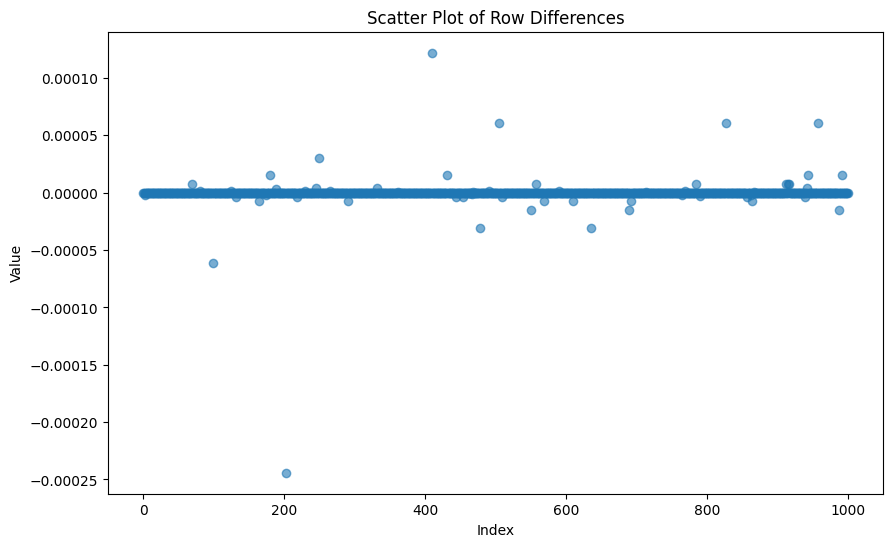

In [ ]:
def plot_scatter_for_row_or_column(tensor_diff, index=0, axis=0, title="Scatter Plot of Differences", max_dots=1000):
    if axis == 0:
        data = tensor_diff[index, :]
    else:
        data = tensor_diff[:, index]
    
    data = np.array(data)
    
    plt.figure(figsize=(10, 6))
    plt.scatter(range(len(data[:max_dots])), data[:max_dots], alpha=0.6)
    plt.title(title)
    plt.xlabel("Index")
    plt.ylabel("Value")
    plt.show()
diff_tensor = diff_state_dict_numpy['language_model']['encoder']['layers.0.mlp.dense_h_to_4h.weight'] 
plot_scatter_for_row_or_column(diff_tensor, index=3525, axis=0, title="Scatter Plot of Row Differences", max_dots=1000)

In [ ]:
def plot_non_zero_heatmap(tensor_diff, title="Non-zero Differences Heatmap"):
    # Create a mask for non-zero values
    non_zero_mask = tensor_diff != 0
    
    # Plot the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(non_zero_mask, cbar=False, cmap='viridis')
    plt.title(title)
    plt.xlabel("D1: rows of the weight matrix")
    plt.ylabel("D2: columns of the weight matrix")
    plt.show()



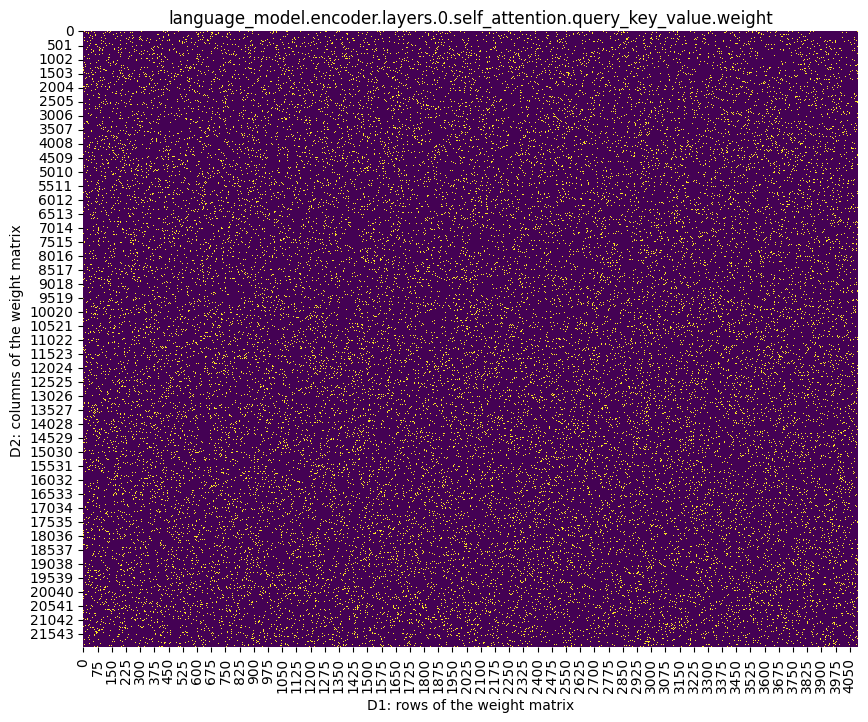

In [ ]:
# Example of accessing and plotting a specific tensor difference
key_to_plot = 'language_model.encoder.layers.0.self_attention.query_key_value.weight'
tensor_diff_to_plot = diff_state_dict_numpy['language_model']['encoder']['layers.0.mlp.dense_h_to_4h.weight']

# Plotting the heatmap of non-zero differences
plot_non_zero_heatmap(tensor_diff_to_plot, title=key_to_plot)


In [ ]:
print(tensor_diff_to_plot.shape)

(22016, 4096)


In [ ]:
def calculate_percentage_of_changes(tensor_diff):
    # Flatten the tensor to a 1D array
    tensor_diff_flat = tensor_diff.flatten()
    
    # Count the number of non-zero elements
    num_non_zero = (tensor_diff_flat != 0).sum()
    
    # Calculate the total number of elements
    total_elements = tensor_diff_flat.size
    
    # Compute the percentage of changed elements
    percentage_changed = (num_non_zero / total_elements) * 100
    
    return percentage_changed

# Example usage
for key in diff_state_dict_numpy['language_model']['encoder'].keys():
    tensor_diff_to_plot = diff_state_dict_numpy['language_model']['encoder'][key]
    percentage_changed = calculate_percentage_of_changes(tensor_diff_to_plot)
    print(f"Percentage of changed elements for key '{key}': {percentage_changed:.2f}%")



Percentage of changed elements for key 'layers.0.input_layernorm.weight': 0.00%
Percentage of changed elements for key 'layers.0.self_attention.query_key_value.weight': 5.76%
Percentage of changed elements for key 'layers.0.self_attention.dense.weight': 7.27%
Percentage of changed elements for key 'layers.0.post_attention_layernorm.weight': 0.00%
Percentage of changed elements for key 'layers.0.mlp.dense_h_to_4h.weight': 5.70%
Percentage of changed elements for key 'layers.0.mlp.dense_4h_to_h.weight': 5.99%
Percentage of changed elements for key 'layers.1.input_layernorm.weight': 0.00%
Percentage of changed elements for key 'layers.1.self_attention.query_key_value.weight': 5.61%
Percentage of changed elements for key 'layers.1.self_attention.dense.weight': 7.12%
Percentage of changed elements for key 'layers.1.post_attention_layernorm.weight': 0.00%
Percentage of changed elements for key 'layers.1.mlp.dense_h_to_4h.weight': 5.72%
Percentage of changed elements for key 'layers.1.mlp.den

In [ ]:
def tensors_to_numpy(data):
    if isinstance(data, dict): 
        return {key: tensors_to_numpy(value) for key, value in data.items()}
    elif isinstance(data, torch.Tensor): 
        if data.dtype == torch.bfloat16:
            data = data.to(torch.float16)
        return data.cpu().numpy()
    else: 
        return data
    
diff_state_dict_numpy = tensors_to_numpy(diff_state_dict)

In [ ]:
def find_max_change(diff_dict):
    max_change = 0
    max_change_key = None

    def recursive_find_max_change(d):
        nonlocal max_change, max_change_key
        for key, value in d.items():
            if isinstance(value, dict):
                recursive_find_max_change(value)
            elif isinstance(value, np.ndarray):
                current_max_change = np.max(np.abs(value))
                if current_max_change > max_change:
                    max_change = current_max_change
                    max_change_key = key
            else:
                raise ValueError(f"Unsupported type for key '{key}': {type(value)}")

    recursive_find_max_change(diff_dict)
    return max_change, max_change_key

# Example usage
max_change, max_change_key = find_max_change(diff_state_dict_numpy)
print(f"Maximum change: {max_change} in key: {max_change_key}")
print(diff_state_dict_numpy)

Maximum change: 0.00048828125 in key: layers.0.self_attention.query_key_value.weight
{'language_model': {'encoder': {'layers.0.input_layernorm.weight': array([0., 0., 0., ..., 0., 0., 0.], dtype=float16), 'layers.0.self_attention.query_key_value.weight': array([[ 0.000e+00,  0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00,
         0.000e+00],
       [ 0.000e+00,  0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00,
         0.000e+00],
       [ 0.000e+00,  0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00,
         0.000e+00],
       ...,
       [ 0.000e+00,  0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00,
         0.000e+00],
       [ 0.000e+00,  0.000e+00,  0.000e+00, ...,  0.000e+00,  0.000e+00,
         1.431e-06],
       [ 0.000e+00, -7.629e-06,  0.000e+00, ...,  1.526e-05,  0.000e+00,
         0.000e+00]], dtype=float16), 'layers.0.self_attention.dense.weight': array([[0.0e+00, 0.0e+00, 0.0e+00, ..., 0.0e+00, 0.0e+00, 0.0e+00],
       [0.0e+00, 0.0e+00, 0.0e+00, ..., 0.0e